## Linear Support Vector Classifier (Linear SVC)

**Linear SVC** is an SVM classifier that uses a **linear kernel** to separate classes with a **straight decision boundary (hyperplane)**.

### Key Points

- Used for **classification** tasks.
- Best when the data is **linearly separable**.
- Faster than non-linear kernels.
- Finds the hyperplane with the **maximum margin** between classes.
- Works best when features are **scaled** (e.g., using `StandardScaler`).


> **Note:** A linear SVC creates a **straight-line decision boundary**, unlike kernels such as **RBF**, which create curved boundaries.

In [179]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets,svm
from sklearn.inspection import DecisionBoundaryDisplay

In [180]:
iris=datasets.load_iris()

In [181]:
print(type (iris))
# <class 'sklearn.utils._bunch.Bunch'> What is a Bunch?
# A Bunch is a special object created by Scikit-Learn.
# You can think of it as a dictionary with extra features.
# It stores several pieces of information together -> data , target , feature_names , DESCR , filename

<class 'sklearn.utils._bunch.Bunch'>


In [182]:
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [183]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [184]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [185]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
print(df.shape)
print(df.head())

(150, 4)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [186]:
df['target']=iris.target
print(df.shape)
print(df.head().to_string())


(150, 5)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target
0                5.1               3.5                1.4               0.2       0
1                4.9               3.0                1.4               0.2       0
2                4.7               3.2                1.3               0.2       0
3                4.6               3.1                1.5               0.2       0
4                5.0               3.6                1.4               0.2       0


In [187]:
# apply() means : "Do the same operation to every value in this column."
# lambda x: is a small anonymous function 
df['flower_name']=df.target.apply(lambda x : iris.target_names[x])
print(df.shape)
print(df.head().to_string())

(150, 6)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target flower_name
0                5.1               3.5                1.4               0.2       0      setosa
1                4.9               3.0                1.4               0.2       0      setosa
2                4.7               3.2                1.3               0.2       0      setosa
3                4.6               3.1                1.5               0.2       0      setosa
4                5.0               3.6                1.4               0.2       0      setosa


In [188]:
# x=df.drop(['petal length (cm)', 'petal width (cm)','target','flower_name'],axis='columns')
x = df[['sepal length (cm)', 'sepal width (cm)']]
y=df['target']
print(x.head().to_string())
print( )
print(y.head().to_string())

   sepal length (cm)  sepal width (cm)
0                5.1               3.5
1                4.9               3.0
2                4.7               3.2
3                4.6               3.1
4                5.0               3.6

0    0
1    0
2    0
3    0
4    0


In [189]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=32,stratify=y)

In [190]:
print(len(x_train))
print(len(x_test))

120
30


In [191]:
from sklearn.svm import SVC # support vector classifier

# kernal='linear' mean the way that you separete between classes is line as tell SVM what kind of decision boundary to use
model=SVC(kernel='linear',random_state=32) # it will apply one versis all since there are 3 class and i use kernel of type linear

In [192]:
model.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [193]:
y_pred=model.predict(x_test)

In [194]:
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_test,y_pred)*100
print(accuracy)

93.33333333333333


Text(0.5, 1.0, 'SVC with Linear Kernel')

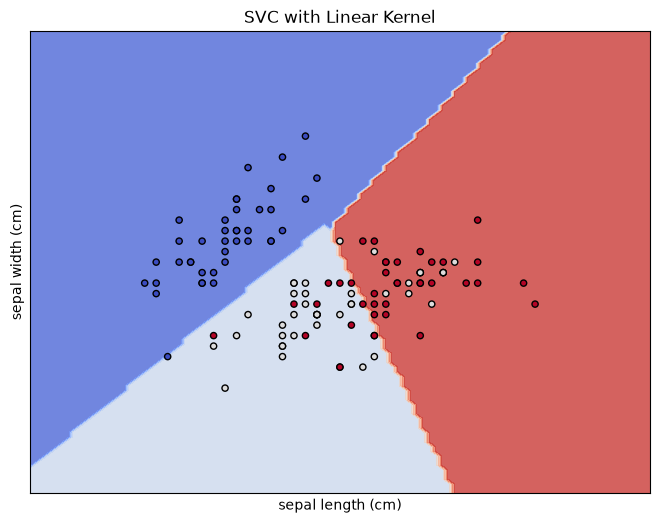

In [195]:

x0=x_train['sepal length (cm)']
x1=x_train['sepal width (cm)']

# Create plot
# subplots()-> create fig,axes object
fig,ax=plt.subplots(figsize=(8,6))
disp=DecisionBoundaryDisplay.from_estimator(model,x_train,response_method='predict',
                                            cmap=plt.cm.coolwarm,alpha=0.8
                                            ,ax=ax,
                                            xlabel=iris.feature_names[0],ylabel=iris.feature_names[1])
ax.scatter(x0,x1,c=y_train,cmap=plt.cm.coolwarm,s=20,edgecolors='k')
ax.set_xticks(())
ax.set_yticks(())
ax.set_title("SVC with Linear Kernel")